In [143]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [144]:
# Load Data set
df=pd.read_csv('./Datasets/students_performance.csv')

In [145]:
# Display first 10 rows
df.head(10)

,Student_ID,Gender,Study_Hours,Attendance,Previous_Score,Final_Score,Internet_Access
0,1,Male,2.0,75,60.0,65.0,Yes
1,2,Female,5.0,88,70.0,78.0,Yes
2,3,Male,1.0,60,50.0,55.0,No
3,4,Female,6.0,92,80.0,90.0,Yes
4,5,Male,3.0,70,65.0,68.0,No
5,6,Female,4.0,85,72.0,76.0,Yes
6,7,Male,2.0,65,55.0,60.0,No
7,8,Female,7.0,95,85.0,93.0,Yes
8,9,Male,5.0,80,68.0,74.0,Yes
9,10,Female,3.0,78,62.0,70.0,Yes


In [146]:
# Display last 5 rows
df.tail()

,Student_ID,Gender,Study_Hours,Attendance,Previous_Score,Final_Score,Internet_Access
48,49,Male,4.0,78,67.0,73.0,Yes
49,50,Female,6.0,93,82.0,91.0,Yes
50,5,Male,3.0,70,65.0,68.0,No
51,10,Female,3.0,78,62.0,70.0,Yes
52,21,Male,5.0,86,73.0,80.0,Yes


In [147]:
# Check dataset shape
df.shape

(53, 7)

In [148]:
# List Column names
df.columns

Index(['Student_ID', 'Gender', 'Study_Hours', 'Attendance', 'Previous_Score',
       'Final_Score', 'Internet_Access'],
      dtype='object')

In [149]:
# Check Datatypes
df.dtypes

Student_ID           int64
Gender              object
Study_Hours        float64
Attendance           int64
Previous_Score     float64
Final_Score        float64
Internet_Access     object
dtype: object

In [150]:
# Identify numerical columns and Categorical Columns
numerical_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Numerical columns:",numerical_cols)
print("Categorical columns:",categorical_cols)

Numerical columns: ['Student_ID', 'Study_Hours', 'Attendance', 'Previous_Score', 'Final_Score']
Categorical columns: ['Gender', 'Internet_Access']


In [151]:
 # Check Missing Values
 df.isnull().sum()

Student_ID         0
Gender             0
Study_Hours        1
Attendance         0
Previous_Score     1
Final_Score        1
Internet_Access    1
dtype: int64

In [152]:
# show rows with null Values
df[df.isnull().any(axis=1)]

,Student_ID,Gender,Study_Hours,Attendance,Previous_Score,Final_Score,Internet_Access
30,31,Male,NaN,67,59.0,63.0,No
31,32,Female,4.0,84,NaN,76.0,Yes
32,33,Male,5.0,85,74.0,NaN,Yes
33,34,Female,3.0,73,64.0,69.0,NaN


In [153]:
# Filling Missing Values 
df["Study_Hours"]=df['Study_Hours'].fillna(df['Study_Hours'].mean())
df[["Previous_Score","Final_Score"]]=df[["Previous_Score","Final_Score"]].fillna(df[["Previous_Score","Final_Score"]].mean())

In [154]:
# Dropping null Values
df.dropna(inplace=True)

In [155]:
# check duplicate rows
df[df.duplicated()]

,Student_ID,Gender,Study_Hours,Attendance,Previous_Score,Final_Score,Internet_Access
50,5,Male,3.0,70,65.0,68.0,No
51,10,Female,3.0,78,62.0,70.0,Yes
52,21,Male,5.0,86,73.0,80.0,Yes


In [156]:
# Remove Duplicates
df.drop_duplicates(inplace=True)

In [157]:
# verify Correct data ranges
df.describe()

,Student_ID,Study_Hours,Attendance,Previous_Score,Final_Score
count,49.000000,49.000000,49.000000,49.000000,49.000000
mean,25.326531,4.207221,80.489796,68.953689,75.140502
std,14.676211,1.743557,10.811110,10.265199,11.656584
min,1.000000,1.000000,55.000000,47.000000,50.000000
25%,13.000000,3.000000,72.000000,62.000000,68.000000
50%,25.000000,4.000000,82.000000,68.730769,74.884615
75%,38.000000,6.000000,89.000000,77.000000,85.000000
max,50.000000,7.000000,97.000000,89.000000,96.000000


In [158]:
# Change Data Types
for column in df.columns:
    if df[column].dtype=='float64':
        df[column] = df[column].astype('int64')

In [159]:
# Verify Clean data
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49 entries, 0 to 49
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Student_ID       49 non-null     int64 
 1   Gender           49 non-null     object
 2   Study_Hours      49 non-null     int64 
 3   Attendance       49 non-null     int64 
 4   Previous_Score   49 non-null     int64 
 5   Final_Score      49 non-null     int64 
 6   Internet_Access  49 non-null     object
dtypes: int64(5), object(2)
memory usage: 3.1+ KB


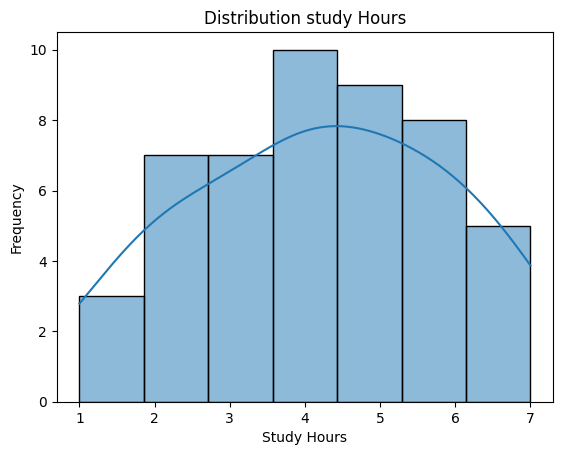

In [160]:
# Distribution of Study Hours 
sns.histplot(df['Study_Hours'],bins=7,kde=True)
plt.title("Distribution study Hours")
plt.xlabel("Study Hours")
plt.ylabel("Frequency")
plt.show()

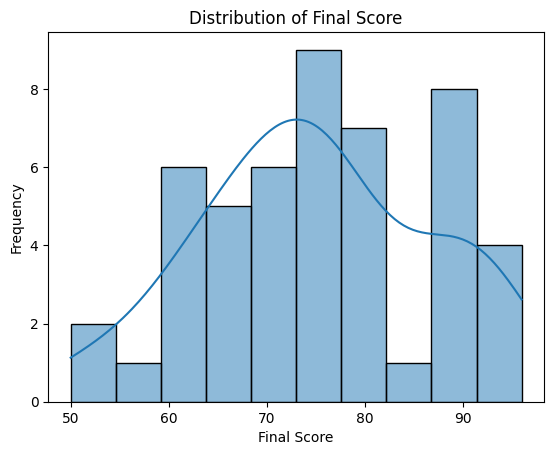

In [161]:
# Distribution of Final Score
sns.histplot(df['Final_Score'],bins=10,kde=True)
plt.title("Distribution of Final Score")
plt.xlabel("Final Score")
plt.ylabel("Frequency")
plt.show()

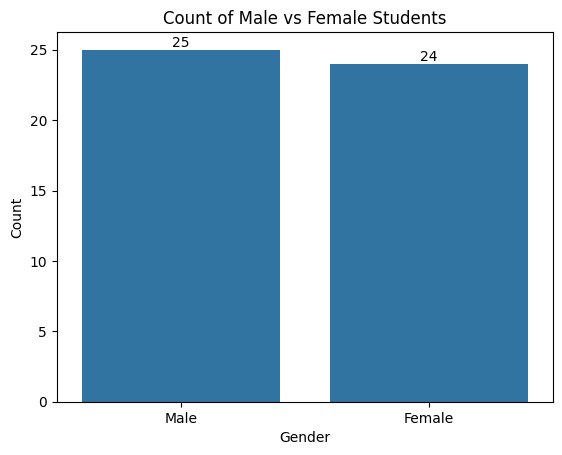

In [162]:
# Count of Male vs Female
ax = sns.countplot(x='Gender',data=df)
for container in ax.containers:
    ax.bar_label(container)
plt.title("Count of Male vs Female Students")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

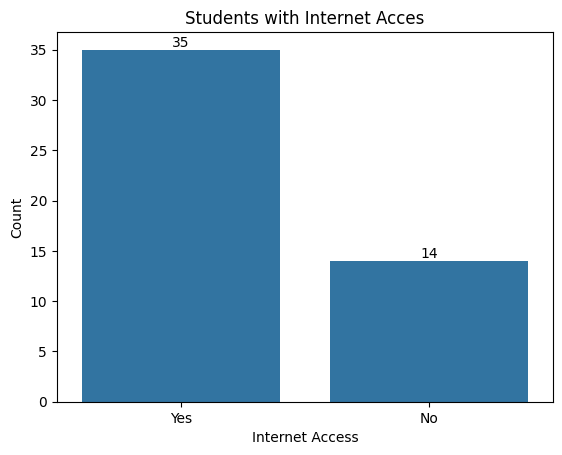

In [163]:
# Count of Internet Acces - shows how many students have internet access
# Count of Male vs Female
ax = sns.countplot(x='Internet_Access',data=df)
for container in ax.containers:
    ax.bar_label(container)
plt.title("Students with Internet Acces")
plt.xlabel("Internet Access")
plt.ylabel("Count")
plt.show()

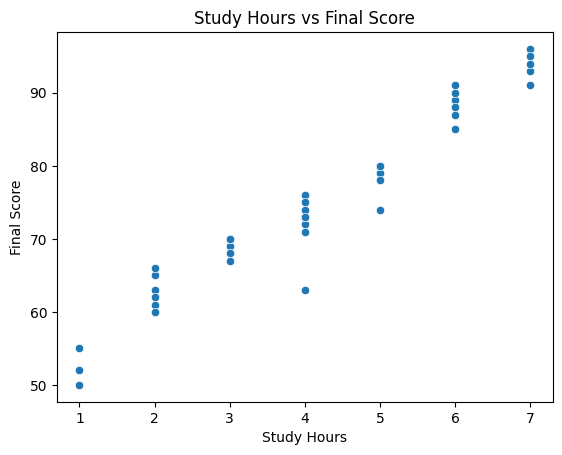

In [164]:
# Study Hours Vs Final Score 
sns.scatterplot(x="Study_Hours",y="Final_Score",data=df)
plt.title("Study Hours vs Final Score")
plt.xlabel("Study Hours")
plt.ylabel("Final Score")
plt.show()

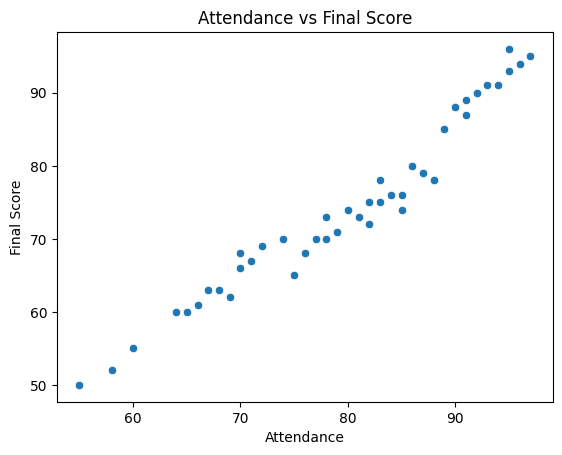

In [165]:
# Attendence vs Final Score
sns.scatterplot(x="Attendance", y="Final_Score", data=df)
plt.title("Attendance vs Final Score")
plt.xlabel("Attendance")
plt.ylabel("Final Score")
plt.show()

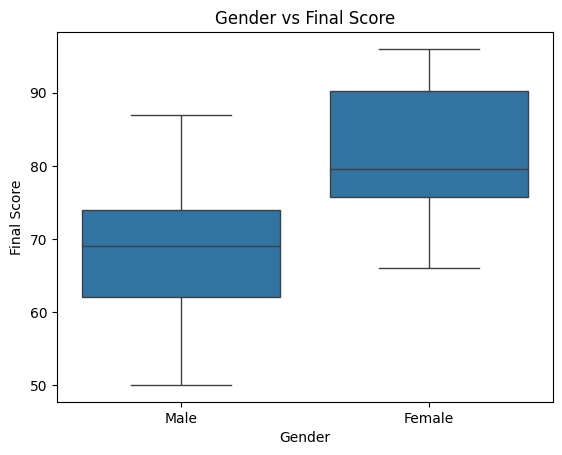

In [166]:
# Gender vs Final Score
sns.boxplot(x="Gender", y="Final_Score", data=df)
plt.title("Gender vs Final Score")
plt.xlabel("Gender")
plt.ylabel("Final Score")
plt.show()

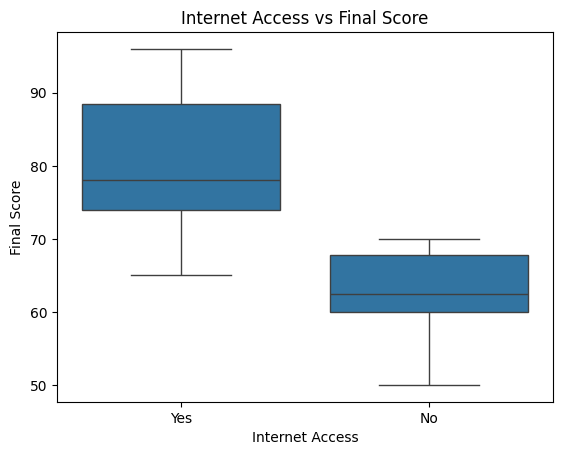

In [167]:
# Internet vs Final score
sns.boxplot(x="Internet_Access", y="Final_Score", data=df)
plt.title("Internet Access vs Final Score")
plt.xlabel("Internet Access")
plt.ylabel("Final Score")
plt.show()

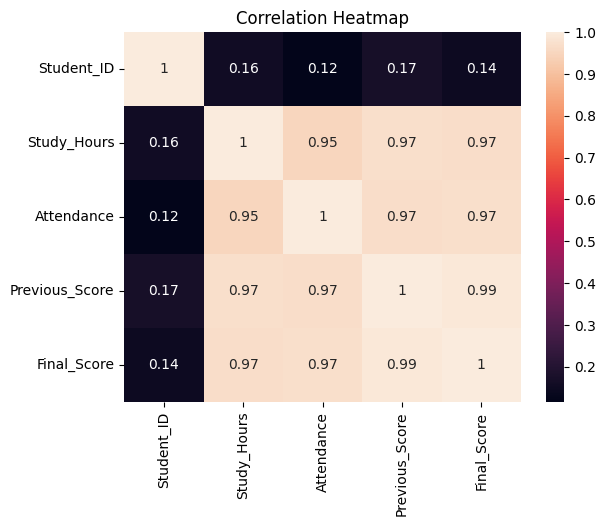

In [168]:
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix,annot=True)
plt.title("Correlation Heatmap")
plt.show()